In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Continual World Results

In [2]:
cw_cpo_0 = pd.read_csv('./results/cw/cpo_0.csv')
cw_cpo_1 = pd.read_csv('./results/cw/cpo_1.csv')
cw_cpo_2 = pd.read_csv('./results/cw/cpo_2.csv')
cw_cpo_3 = pd.read_csv('./results/cw/cpo_3.csv')
cw_cpo_4 = pd.read_csv('./results/cw/cpo_4.csv')

cpo_list = [cw_cpo_0, cw_cpo_1, cw_cpo_2, cw_cpo_3, cw_cpo_4]

cw_cpo_rewards = [results['Metrics/EpSuccess'] for results in cpo_list]
cw_cpo_costs = [results['Metrics/EpCost'] for results in cpo_list]

cw_cpo_mean_rewards = np.mean(cw_cpo_rewards, axis=0)
cw_cpo_mean_costs = np.mean(cw_cpo_costs, axis=0)

cw_cpo_std_rewards = np.std(cw_cpo_rewards, axis=0)
cw_cpo_std_costs = np.std(cw_cpo_costs, axis=0)

In [3]:
cf_ewc_0 = pd.read_csv('./results/cw/cf_ewc_0.csv')
cf_ewc_1 = pd.read_csv('./results/cw/cf_ewc_1.csv')
cf_ewc_2 = pd.read_csv('./results/cw/cf_ewc_2.csv')
cf_ewc_3 = pd.read_csv('./results/cw/cf_ewc_3.csv')
cf_ewc_4 = pd.read_csv('./results/cw/cf_ewc_4.csv')

cf_list = [cf_ewc_0, cf_ewc_1, cf_ewc_2, cf_ewc_3, cf_ewc_4]

cw_cf_rewards = [results['Metrics/EpSuccess'] for results in cf_list]
cw_cf_costs = [results['Metrics/EpCost'] for results in cf_list]

cw_cf_mean_rewards = np.mean(cw_cf_rewards, axis=0)
cw_cf_mean_costs = np.mean(cw_cf_costs, axis=0)

cw_cf_std_rewards = np.std(cw_cf_rewards, axis=0)
cw_cf_std_costs = np.std(cw_cf_costs, axis=0)

In [4]:
cw_ppo_0 = pd.read_csv('./results/cw/ppo_0.csv')
cw_ppo_1 = pd.read_csv('./results/cw/ppo_1.csv')
cw_ppo_2 = pd.read_csv('./results/cw/ppo_2.csv')
cw_ppo_3 = pd.read_csv('./results/cw/ppo_3.csv')
cw_ppo_4 = pd.read_csv('./results/cw/ppo_4.csv')

ppo_list = [cw_ppo_0, cw_ppo_1, cw_ppo_2, cw_ppo_3, cw_ppo_4]

cw_ppo_rewards = [results['Metrics/EpSuccess'] for results in ppo_list]
cw_ppo_costs = [results['Metrics/EpCost'] for results in ppo_list]

cw_ppo_mean_rewards = np.mean(cw_ppo_rewards, axis=0)
cw_ppo_mean_costs = np.mean(cw_ppo_costs, axis=0)

cw_ppo_std_rewards = np.std(cw_ppo_rewards, axis=0)
cw_ppo_std_costs = np.std(cw_ppo_costs, axis=0)

In [5]:
cw_ppolag_0 = pd.read_csv('./results/cw/ppo_lag_0.csv')
cw_ppolag_1 = pd.read_csv('./results/cw/ppo_lag_1.csv')
cw_ppolag_2 = pd.read_csv('./results/cw/ppo_lag_2.csv')
cw_ppolag_3 = pd.read_csv('./results/cw/ppo_lag_3.csv')
cw_ppolag_4 = pd.read_csv('./results/cw/ppo_lag_4.csv')

ppolag_list = [cw_ppolag_0, cw_ppolag_1, cw_ppolag_2, cw_ppolag_3, cw_ppolag_4]

cw_ppolag_rewards = [results['Metrics/EpSuccess'] for results in ppolag_list]
cw_ppolag_costs = [results['Metrics/EpCost'] for results in ppolag_list]

cw_ppolag_mean_rewards = np.mean(cw_ppolag_rewards, axis=0)
cw_ppolag_mean_costs = np.mean(cw_ppolag_costs, axis=0)

cw_ppolag_std_rewards = np.std(cw_ppolag_rewards, axis=0)
cw_ppolag_std_costs = np.std(cw_ppolag_costs, axis=0)

In [6]:
cw_cppo_pid_0 = pd.read_csv('./results/cw/cppo_pid_0.csv')
cw_cppo_pid_1 = pd.read_csv('./results/cw/cppo_pid_1.csv')
cw_cppo_pid_2 = pd.read_csv('./results/cw/cppo_pid_2.csv')
cw_cppo_pid_3 = pd.read_csv('./results/cw/cppo_pid_3.csv')
cw_cppo_pid_4 = pd.read_csv('./results/cw/cppo_pid_4.csv')

cppo_pid_list = [cw_cppo_pid_0, cw_cppo_pid_1, cw_cppo_pid_2, cw_cppo_pid_3, cw_cppo_pid_4]

cw_cppo_pid_rewards = [results['Metrics/EpSuccess'] for results in cppo_pid_list]
cw_cppo_pid_costs = [results['Metrics/EpCost'] for results in cppo_pid_list]

cw_cppo_pid_mean_rewards = np.mean(cw_cppo_pid_rewards, axis=0)
cw_cppo_pid_mean_costs = np.mean(cw_cppo_pid_costs, axis=0)

cw_cppo_pid_std_rewards = np.std(cw_cppo_pid_rewards, axis=0)
cw_cppo_pid_std_costs = np.std(cw_cppo_pid_costs, axis=0)

In [7]:
def add_task_names(results, task_sequence, task_length):
    task_names = [[task] * task_length for task in task_sequence]
    task_names = np.concatenate(task_names)
    results['task'] = task_names

    return results

def all_average_total_costs(results, task_length):
    faucet_cost = average_total_costs(results, 'faucet', task_length)
    button_press_cost = average_total_costs(results, 'button', task_length)
    drawer_close_cost = average_total_costs(results, 'drawer', task_length)

    return faucet_cost, button_press_cost, drawer_close_cost

def average_total_costs(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_costs = task_results['Metrics/EpCost'].to_numpy()

    num_visited = int(len(task_costs) / task_length)

    total_costs = []
    for i in range(num_visited):
        task_idx = np.arange(0, task_length) + i * task_length
        total_costs.append(task_costs[task_idx].sum())

    return np.mean(total_costs)

def all_forgetting(results, task_length):
    faucet_forget, faucet_rew_forget = forgetting(results, 'faucet', task_length)
    button_forget, button_rew_forget = forgetting(results, 'button', task_length)
    drawer_forget, drawer_rew_forget = forgetting(results, 'drawer', task_length)

    return faucet_forget, button_forget, drawer_forget, faucet_rew_forget, button_rew_forget, drawer_rew_forget

def forgetting(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_rewards = task_results['Metrics/EpSuccess'].to_numpy()

    endpoint = task_length - 1
    startpoint = task_length + 1 # to purge the buffer

    num_visited = int(len(task_rewards) / task_length)
    num_restart = num_visited - 1

    forget_values = []
    abs_forget = []
    for i in range(num_restart):
        A = task_rewards[endpoint * (i+1)]
        B = task_rewards[startpoint * (i+1)]
        forget = (A - B) / (np.abs(A)) * 100

        forget_values.append(forget)
        abs_forget.append(A-B)
    
    return np.mean(forget_values), np.mean(abs_forget)

def all_rewards(results, task_length):
    faucet_rew = rewards(results, 'faucet', task_length)
    button_rew = rewards(results, 'button', task_length)
    drawer_rew = rewards(results, 'drawer', task_length)

    return faucet_rew, button_rew, drawer_rew


def rewards(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_rewards = task_results['Metrics/EpSuccess'].to_numpy()

    endpoint = task_length - 1

    num_visited = int(len(task_rewards) / task_length)

    reward_vals = []
    for i in range(num_visited):
        rew = task_rewards[endpoint * (i+1)]
        reward_vals.append(rew)
    
    return reward_vals[-1]
    

In [8]:
def all_success_rates(results, task_length):
    faucet_success_rate = success_rate(results, 'faucet', task_length)
    button_success_rate = success_rate(results, 'button', task_length)
    drawer_success_rate = success_rate(results, 'drawer', task_length)

    return faucet_success_rate, button_success_rate, drawer_success_rate

def success_rate(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_success = task_results['Metrics/EpSuccess'].to_numpy()

    endpoint = task_length - 1

    num_visited = int(len(task_success) / task_length)

    success_vals = []
    for i in range(num_visited):
        success = task_success[endpoint * (i+1)]
        success_vals.append(success)
    
    return np.mean(success_vals)

def all_success_forgetting(results, task_length):
    faucet_success_forgetting_rate = success_forgetting(results, 'faucet', task_length)
    button_success_forgetting_rate = success_forgetting(results, 'button', task_length)
    drawer_success_forgetting_rate = success_forgetting(results, 'drawer', task_length)

    return faucet_success_forgetting_rate, button_success_forgetting_rate, drawer_success_forgetting_rate

def success_forgetting(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_success = task_results['Metrics/EpSuccess'].to_numpy()

    endpoint = task_length - 1
    startpoint = task_length + 1 # to purge the buffer

    num_visited = int(len(task_success) / task_length)
    num_restart = num_visited - 1

    forget_values = []
    for i in range(num_restart):
        A = task_success[endpoint * (i+1)]
        B = task_success[startpoint * (i+1)]

        forget_values.append(A-B)
    
    return np.mean(forget_values)

def aggregate_metrics(results_list, task_sequence, task_length):
    faucet_costs, button_costs, drawer_costs = [], [], []
    faucet_forgets, button_forgets, drawer_forgets = [], [], []
    faucet_rew_forgets, button_rew_forgets, drawer_rew_forgets = [], [], []
    faucet_rewards, button_rewards, drawer_rewards = [], [], []
    faucet_success, button_success, drawer_success = [], [], []
    faucet_success_forgetting, button_success_forgetting, drawer_success_forgetting = [], [], []

    for result in results_list:
        faucet_cost, button_cost, drawer_cost, \
        faucet_forget, button_forget, drawer_forget, \
        faucet_rew, button_rew, drawer_rew, \
        faucet_rew_forget, button_rew_forget, drawer_rew_forget, \
        faucet_success_rate, button_success_rate, drawer_success_rate, \
        faucet_success_forgetting_rate, button_success_forgetting_rate, drawer_success_forgetting_rate = calculate_metrics(result, task_sequence, task_length)

        faucet_costs.append(faucet_cost)
        button_costs.append(button_cost)
        drawer_costs.append(drawer_cost)
        
        faucet_forgets.append(faucet_forget)
        button_forgets.append(button_forget)
        drawer_forgets.append(drawer_forget)
        
        faucet_rewards.append(faucet_rew)
        button_rewards.append(button_rew)
        drawer_rewards.append(drawer_rew)
        
        faucet_rew_forgets.append(faucet_rew_forget)
        button_rew_forgets.append(button_rew_forget)
        drawer_rew_forgets.append(drawer_rew_forget)
        
        faucet_success.append(faucet_success_rate)
        button_success.append(button_success_rate)
        drawer_success.append(drawer_success_rate)
        
        faucet_success_forgetting.append(faucet_success_forgetting_rate)
        button_success_forgetting.append(button_success_forgetting_rate)
        drawer_success_forgetting.append(drawer_success_forgetting_rate)

    tasks = ['faucet', 'button', 'drawer']
    cost_lists = [faucet_costs, button_costs, drawer_costs]
    forget_lists = [faucet_forgets, button_forgets, drawer_forgets]
    reward_lists = [faucet_rewards, button_rewards, drawer_rewards]
    rew_forget_lists = [faucet_rew_forgets, button_rew_forgets, drawer_rew_forgets]
    success_lists = [faucet_success, button_success, drawer_success]
    success_forgetting_lists = [faucet_success_forgetting, button_success_forgetting, drawer_success_forgetting]

    for task, costs, forgets, rewards, rew_forgets, success, success_forgetting in zip(tasks, cost_lists, forget_lists, reward_lists, rew_forget_lists, success_lists, success_forgetting_lists):
        print(f"{task.upper()}:")
        print(f"Total costs: {np.mean(costs)} +/- {np.std(costs)}")
        print(f"Reward forgetting: {np.mean(rew_forgets)} +/- {np.std(rew_forgets)}")
        print(f"Rewards: {np.mean(rewards)} +/- {np.std(rewards)}")
        print(f"Success rate: {np.mean(success)} +/- {np.std(success)}")
        print(f"Success forgetting rate: {np.mean(success_forgetting)} +/- {np.std(success_forgetting)}")
        print()

    print(f'OVERALL COSTS: {np.mean(cost_lists)} +/- {np.std(cost_lists)}')
    print(f'OVERALL REWARD: {np.mean(reward_lists)} +/- {np.std(reward_lists)}')
    print(f'OVERALL REWARD FORGET: {np.mean(rew_forget_lists)} +/- {np.std(rew_forget_lists)}')
    print(f'OVERALL SUCCESS: {np.mean(success_lists)} +/- {np.std(success_lists)}')
    print(f'OVERALL SUCCESS FORGET: {np.mean(success_forgetting_lists)} +/- {np.std(success_forgetting_lists)}')

    initial = [r['Metrics/EpSuccess'][0] for r in results_list]
    possible_forgetting = np.mean([np.mean(faucet_success), np.mean(button_success), np.mean(drawer_success)]) - np.mean(initial)
    norm_forget = np.mean([np.mean(faucet_success_forgetting), np.mean(button_success_forgetting), np.mean(drawer_success_forgetting)]) / possible_forgetting
    print(np.mean([np.mean(faucet_success_forgetting), np.mean(button_success_forgetting), np.mean(drawer_success_forgetting)]), possible_forgetting)
    print(f'NORMALIZED FORGETTING RATE: {norm_forget}')

def calculate_metrics(results, task_sequence, task_length):
    results = add_task_names(results, task_sequence, task_length)
    faucet_cost, button_cost, drawer_cost = all_average_total_costs(results, task_length)
    faucet_forget, button_forget, drawer_forget, faucet_rew_forget, button_rew_forget, drawer_rew_forget = all_forgetting(results, task_length)
    faucet_rew, button_rew, drawer_rew = all_rewards(results, task_length)
    faucet_success_rate, button_success_rate, drawer_success_rate = all_success_rates(results, task_length)
    faucet_success_forgetting_rate, button_success_forgetting_rate, drawer_success_forgetting_rate = all_success_forgetting(results, task_length)

    return  faucet_cost, button_cost, drawer_cost, \
            faucet_forget, button_forget, drawer_forget, \
            faucet_rew, button_rew, drawer_rew, \
            faucet_rew_forget, button_rew_forget, drawer_rew_forget, \
            faucet_success_rate, button_success_rate, drawer_success_rate, \
            faucet_success_forgetting_rate, button_success_forgetting_rate, drawer_success_forgetting_rate

In [9]:
tasks_encountered = ['faucet', 'button', 'drawer', 
                     'faucet', 'button', 'drawer']


aggregate_metrics(cpo_list, tasks_encountered, 100)

FAUCET:
Total costs: 106108.0783793944 +/- 39016.198262636484
Reward forgetting: 0.37 +/- 0.33776008497156673
Rewards: 0.61175 +/- 0.41290404454303914
Success rate: 0.6472499999999999 +/- 0.28684125618536815
Success forgetting rate: 0.37 +/- 0.33776008497156673

BUTTON:
Total costs: 91956.57225 +/- 134588.45214002187
Reward forgetting: 0.81175 +/- 0.14555840752082994
Rewards: 0.8205 +/- 0.3521652666007822
Success rate: 0.9012499999999999 +/- 0.17237631435321968
Success forgetting rate: 0.81175 +/- 0.14555840752082994

DRAWER:
Total costs: 8388.136375000002 +/- 14744.493533552477
Reward forgetting: 0.23674999999999996 +/- 0.3763920828072769
Rewards: 0.9960000000000001 +/- 0.008000000000000007
Success rate: 0.998 +/- 0.0040000000000000036
Success forgetting rate: 0.23674999999999996 +/- 0.3763920828072769

OVERALL COSTS: 68817.59566813147 +/- 92071.39829942262
OVERALL REWARD: 0.8094166666666667 +/- 0.3505150575304228
OVERALL REWARD FORGET: 0.4728333333333334 +/- 0.3907747290817164
OVERAL

In [10]:
aggregate_metrics(cf_list, tasks_encountered, 100)

FAUCET:
Total costs: 215464.74683989916 +/- 288290.2048892084
Reward forgetting: 0.7212500000000001 +/- 0.2944698626345318
Rewards: 0.38525 +/- 0.39473598771837365
Success rate: 0.669875 +/- 0.18738554840221805
Success forgetting rate: 0.7212500000000001 +/- 0.2944698626345318

BUTTON:
Total costs: 156723.5135 +/- 290024.0484779441
Reward forgetting: 0.48 +/- 0.1779694496254905
Rewards: 0.5740000000000001 +/- 0.12331970645440249
Success rate: 0.7148749999999999 +/- 0.09549165539459455
Success forgetting rate: 0.48 +/- 0.1779694496254905

DRAWER:
Total costs: 6587.914375 +/- 7541.1407463164405
Reward forgetting: 0.013000000000000012 +/- 0.024617067250182364
Rewards: 0.9924999999999999 +/- 0.010000000000000004
Success rate: 0.99475 +/- 0.006442049363362534
Success forgetting rate: 0.013000000000000012 +/- 0.024617067250182364

OVERALL COSTS: 126258.72490496638 +/- 251984.77488454818
OVERALL REWARD: 0.6505833333333333 +/- 0.3484719221910935
OVERALL REWARD FORGET: 0.40475 +/- 0.35510303669

In [11]:
aggregate_metrics(ppolag_list, tasks_encountered, 100)


FAUCET:
Total costs: 30670.842589899148 +/- 12497.800432032443
Reward forgetting: 0.015249999999999996 +/- 0.026105554964413222
Rewards: 0.02799999999999998 +/- 0.05599999999999996
Success rate: 0.039749999999999994 +/- 0.06769601169936082
Success forgetting rate: 0.015249999999999996 +/- 0.026105554964413222

BUTTON:
Total costs: 14895.110250000002 +/- 8754.31089797525
Reward forgetting: -0.025249999999999995 +/- 0.05049999999999999
Rewards: 0.04549999999999998 +/- 0.09099999999999994
Success rate: 0.039874999999999994 +/- 0.07974999999999999
Success forgetting rate: -0.025249999999999995 +/- 0.05049999999999999

DRAWER:
Total costs: 121709.39099999997 +/- 146814.46736588608
Reward forgetting: 0.018999999999999996 +/- 0.10796816660479144
Rewards: 0.27425 +/- 0.3358455746321514
Success rate: 0.27524999999999994 +/- 0.31760938076511525
Success forgetting rate: 0.018999999999999996 +/- 0.10796816660479144

OVERALL COSTS: 55758.44794663305 +/- 97358.52642465183
OVERALL REWARD: 0.115916666

/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100


In [12]:
aggregate_metrics(ppo_list, tasks_encountered, 100)


FAUCET:
Total costs: 289830.67762500007 +/- 362416.11533084937
Reward forgetting: 0.7557499999999999 +/- 0.21378961621182638
Rewards: 0.8055 +/- 0.19991967136827737
Success rate: 0.8977499999999999 +/- 0.10054119180713944
Success forgetting rate: 0.7557499999999999 +/- 0.21378961621182638

BUTTON:
Total costs: 42503.865125 +/- 41154.583361813144
Reward forgetting: 0.40374999999999994 +/- 0.3342557030179141
Rewards: 0.6609999999999999 +/- 0.36097645352571134
Success rate: 0.772875 +/- 0.2177418195937565
Success forgetting rate: 0.40374999999999994 +/- 0.3342557030179141

DRAWER:
Total costs: 4295.641750000001 +/- 6958.19795763447
Reward forgetting: 0.014250000000000007 +/- 0.01870160420926505
Rewards: 1.0 +/- 0.0
Success rate: 1.0 +/- 0.0
Success forgetting rate: 0.014250000000000007 +/- 0.01870160420926505

OVERALL COSTS: 112210.06150000003 +/- 245724.17868935855
OVERALL REWARD: 0.8221666666666666 +/- 0.2757710654792405
OVERALL REWARD FORGET: 0.39125 +/- 0.3798807378638722
OVERALL SUCC

In [13]:
aggregate_metrics(cppo_pid_list, tasks_encountered, 100)

FAUCET:
Total costs: 23787.352124999998 +/- 18894.641003325003
Reward forgetting: -0.01424999999999998 +/- 0.028499999999999956
Rewards: 0.006750000000000001 +/- 0.007053367989832943
Success rate: 0.00425 +/- 0.0035881750236018313
Success forgetting rate: -0.01424999999999998 +/- 0.028499999999999956

BUTTON:
Total costs: 25539.4815 +/- 25032.902732620005
Reward forgetting: 0.0017500000000000003 +/- 0.0035000000000000005
Rewards: 0.0017500000000000003 +/- 0.0035000000000000005
Success rate: 0.0017500000000000003 +/- 0.0035000000000000005
Success forgetting rate: 0.0017500000000000003 +/- 0.0035000000000000005

DRAWER:
Total costs: 4843.231374999999 +/- 6352.2913281777755
Reward forgetting: -0.009750000000000002 +/- 0.04944946915791918
Rewards: 0.02375 +/- 0.019669138262770943
Success rate: 0.030000000000000006 +/- 0.02781074432660874
Success forgetting rate: -0.009750000000000002 +/- 0.04944946915791918

OVERALL COSTS: 18056.68833333333 +/- 20715.802573891484
OVERALL REWARD: 0.01075000

/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100


In [14]:
cw_ewc_0 = pd.read_csv('./results/cw/ppo_ewc_0.csv')
cw_ewc_1 = pd.read_csv('./results/cw/ppo_ewc_1.csv')
cw_ewc_2 = pd.read_csv('./results/cw/ppo_ewc_2.csv')
cw_ewc_3 = pd.read_csv('./results/cw/ppo_ewc_3.csv')
cw_ewc_4 = pd.read_csv('./results/cw/ppo_ewc_4.csv')

ewc_list = [cw_ewc_0, cw_ewc_1, cw_ewc_2, cw_ewc_3, cw_ewc_4]

cw_ewc_rewards = [results['Metrics/EpSuccess'] for results in ewc_list]
cw_ewc_costs = [results['Metrics/EpCost'] for results in ewc_list]

cw_ewc_mean_rewards = np.mean(cw_ewc_rewards, axis=0)
cw_ewc_mean_costs = np.mean(cw_ewc_costs, axis=0)

cw_ewc_std_rewards = np.std(cw_ewc_rewards, axis=0)
cw_ewc_std_costs = np.std(cw_ewc_costs, axis=0)

In [15]:
aggregate_metrics(ewc_list, tasks_encountered, 100)

FAUCET:
Total costs: 236857.96321489918 +/- 264564.401248641
Reward forgetting: 0.70225 +/- 0.18444070863017198
Rewards: 0.6452500000000001 +/- 0.42639946060003403
Success rate: 0.789125 +/- 0.214500364218805
Success forgetting rate: 0.70225 +/- 0.18444070863017198

BUTTON:
Total costs: 114343.78612500001 +/- 181560.01577154052
Reward forgetting: 0.25149999999999995 +/- 0.30927879817407467
Rewards: 0.8029999999999999 +/- 0.21576115266655396
Success rate: 0.849 +/- 0.12611415959359992
Success forgetting rate: 0.25149999999999995 +/- 0.30927879817407467

DRAWER:
Total costs: 39556.893500000006 +/- 77616.02595735036
Reward forgetting: 0.011250000000000005 +/- 0.016507574019219172
Rewards: 1.0 +/- 0.0
Success rate: 1.0 +/- 0.0
Success forgetting rate: 0.011250000000000005 +/- 0.016507574019219172

OVERALL COSTS: 130252.88094663307 +/- 207224.60779133142
OVERALL REWARD: 0.8160833333333334 +/- 0.31174237048491743
OVERALL REWARD FORGET: 0.3216666666666667 +/- 0.3540573360660985
OVERALL SUCCES

In [16]:
def convert_reward(safe_ewc):
    safe_ewc['Metrics/EpRet'] += 5* safe_ewc['Metrics/EpCost']
    return safe_ewc

In [17]:
safe_ewc_0 = convert_reward(pd.read_csv('./results/cw/safe_ewc_0.csv'))
safe_ewc_1 = convert_reward(pd.read_csv('./results/cw/safe_ewc_1.csv'))
safe_ewc_2 = convert_reward(pd.read_csv('./results/cw/safe_ewc_2.csv'))
safe_ewc_3 = convert_reward(pd.read_csv('./results/cw/safe_ewc_3.csv'))
safe_ewc_4 = convert_reward(pd.read_csv('./results/cw/safe_ewc_4.csv'))

safe_ewc_list = [safe_ewc_0, safe_ewc_1, safe_ewc_2, safe_ewc_3, safe_ewc_4]

safe_ewc_rewards = [results['Metrics/EpSuccess'] for results in safe_ewc_list]
safe_ewc_costs = [results['Metrics/EpCost'] for results in safe_ewc_list]

safe_ewc_mean_rewards = np.mean(safe_ewc_rewards, axis=0)
safe_ewc_mean_costs = np.mean(safe_ewc_costs, axis=0)

safe_ewc_std_rewards = np.std(safe_ewc_rewards, axis=0)
safe_ewc_std_costs = np.std(safe_ewc_costs, axis=0)

In [18]:
aggregate_metrics(safe_ewc_list, tasks_encountered, 100)

FAUCET:
Total costs: 16749.544339899145 +/- 4495.903772527532
Reward forgetting: -0.0115 +/- 0.038270419386257054
Rewards: 0.024749999999999977 +/- 0.03824591481452622
Success rate: 0.02849999999999999 +/- 0.04399680386118971
Success forgetting rate: -0.0115 +/- 0.038270419386257054

BUTTON:
Total costs: 16120.779999999999 +/- 13976.509111428719
Reward forgetting: -0.0335 +/- 0.06700000000000002
Rewards: 0.0017500000000000003 +/- 0.0035000000000000005
Success rate: 0.0008750000000000001 +/- 0.0017500000000000003
Success forgetting rate: -0.0335 +/- 0.06700000000000002

DRAWER:
Total costs: 42171.925749999995 +/- 30738.531275682388
Reward forgetting: 0.07449999999999997 +/- 0.12998701858262618
Rewards: 0.35125000000000006 +/- 0.2724174186794963
Success rate: 0.38875000000000004 +/- 0.2858635491803738
Success forgetting rate: 0.07449999999999997 +/- 0.12998701858262618

OVERALL COSTS: 25014.083363299716 +/- 23109.869954975362
OVERALL REWARD: 0.12591666666666668 +/- 0.22517653568305515
OV

/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100
/tmp/ipykernel_48853/2889840365.py:50: RuntimeWarning: invalid value encountered in scalar divide
  forget = (A - B) / (np.abs(A)) * 100


In [19]:
def plot_rewards(algorithms, ymax=None, save=False, name=None, xrange=None):
    plt.figure(figsize=(10,3))

    TASK_CYCLE =  ['faucet', 'button', 'drawer', 
                     'faucet', 'button', 'drawer']
    algorithm_colors={'PPO+EWC': 'blue', 
                    'CPO': 'orange',
                    'Safe EWC': 'green',
                    'PPO-Lag': 'purple',
                    'CPPO-PID': 'red',
                    'PPO': 'black',
                    'Exp. Replay': 'brown',
                    'CF': 'brown'}
    cycle_colors = {
        'faucet': 'red',
        'button': 'green',
        'drawer': 'purple'
    }

    cycle_hatches = {
        'faucet': 'xx',
        'button': '/',
        'drawer': '*'
    }

    if 'PPO+EWC' in algorithms:
        plt.plot(cw_ewc_0['Train/TotalSteps'], cw_ewc_mean_rewards, label='PPO+EWC', color='blue')
        plt.fill_between(
            cw_ewc_0['Train/TotalSteps'],
            cw_ewc_mean_rewards - cw_ewc_std_rewards,
            cw_ewc_mean_rewards + cw_ewc_std_rewards,
            color='blue', alpha=0.2
        )

    if 'CPO' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], cw_cpo_mean_rewards, label='CPO', color='orange')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_cpo_mean_rewards - cw_cpo_std_rewards,
            cw_cpo_mean_rewards + cw_cpo_std_rewards,
            color='orange', alpha=0.2
        )

    if 'Safe EWC' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], safe_ewc_mean_rewards, label='Safe EWC', color='green')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            safe_ewc_mean_rewards - safe_ewc_std_rewards,
            safe_ewc_mean_rewards + safe_ewc_std_rewards,
            color='green', alpha=0.2
        )

    if 'PPO-Lag' in algorithms:
        plt.plot(cw_ppolag_0['Train/TotalSteps'], cw_ppolag_mean_rewards, label='PPO-Lag', color='purple')
        plt.fill_between(
            cw_ppolag_0['Train/TotalSteps'],
            cw_ppolag_mean_rewards - cw_ppolag_std_rewards,
            cw_ppolag_mean_rewards + cw_ppolag_std_rewards,
            color='purple', alpha=0.2
        )

    if 'CPPO-PID' in algorithms:
        plt.plot(cw_cppo_pid_0['Train/TotalSteps'], cw_cppo_pid_mean_rewards, label='CPPO-PID', color='red', alpha=0.5)
        plt.fill_between(
            cw_cppo_pid_0['Train/TotalSteps'],
            cw_cppo_pid_mean_rewards - cw_cppo_pid_std_rewards,
            cw_cppo_pid_mean_rewards + cw_cppo_pid_std_rewards,
            color='red', alpha=0.2
        )

    if 'PPO' in algorithms:
        plt.plot(cw_ppo_0['Train/TotalSteps'], cw_ppo_mean_rewards, label='PPO', color='black', alpha=0.5)
        plt.fill_between(
            cw_ppo_0['Train/TotalSteps'],
            cw_ppo_mean_rewards - cw_ppo_std_rewards,
            cw_ppo_mean_rewards + cw_ppo_std_rewards,
            color='black', alpha=0.2
        )

    if 'CF' in algorithms:
        plt.plot(cw_ppo_0['Train/TotalSteps'], cw_cf_mean_rewards, label='CF-EWC', color='brown', alpha=0.5)
        plt.fill_between(
            cw_ppo_0['Train/TotalSteps'],
            cw_cf_mean_rewards - cw_cf_std_rewards,
            cw_cf_mean_rewards + cw_cf_std_rewards,
            color='brown', alpha=0.2
        )

    x_vals = range(0, max(cw_cpo_0['Train/TotalSteps']) + 1, 2000000)
    for i, x in enumerate(x_vals[:-1]):  # Exclude the last x-value as it doesn't define a region
        # Get the current task from the cycle
        task = TASK_CYCLE[i % len(TASK_CYCLE)]
        
        # Shade the region between the current and next x value
        plt.axvline(x=x, color='gray', linestyle='--', linewidth=1)
        plt.fill_between([x, x_vals[i + 1]], cw_ewc_0['Metrics/EpSuccess'].min(), 1, color=cycle_colors[task],  hatch=cycle_hatches[task], alpha=0.1)

    plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='Task Change')

    legend_patches = []
    for task in cycle_colors:
        patch = mpatches.Patch(
            facecolor=cycle_colors[task], 
            hatch=cycle_hatches[task], 
            label=task,
            edgecolor='gray',  
            alpha=0.3
        )
        legend_patches.append(patch)

    for algorithm in algorithms:
        custom_line = Line2D([0], [0], color=algorithm_colors[algorithm], lw=2, linestyle='--', label=algorithm.upper())
        legend_patches.append(custom_line)
    # Add legend to the plot
    plt.legend(handles=legend_patches, title='Task/Algorithm')

    plt.xlabel("Training Timesteps")
    plt.ylabel("Success Rate")
    plt.title("Safe Continual World")
    if ymax is not None:
        plt.ylim(0, ymax)

    if xrange is not None:
        plt.xlim(xrange[0], xrange[1])

    if save:
        plt.savefig(f'./results/plots/{name}.png', bbox_inches='tight')

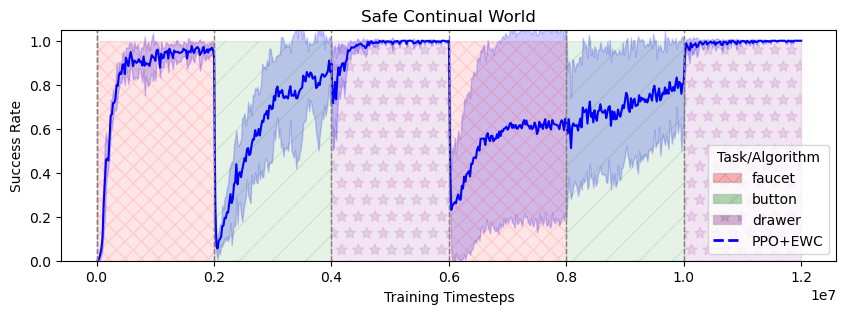

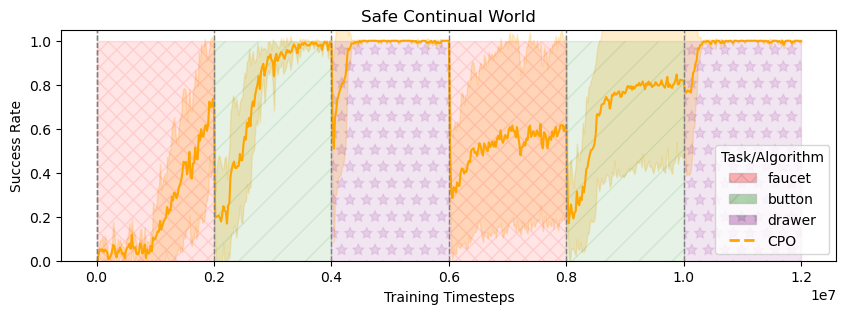

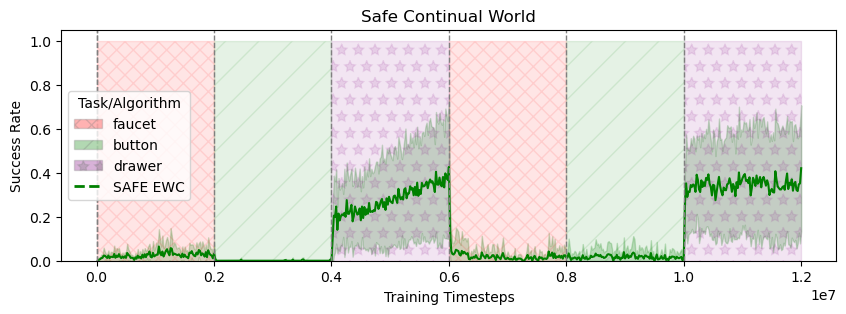

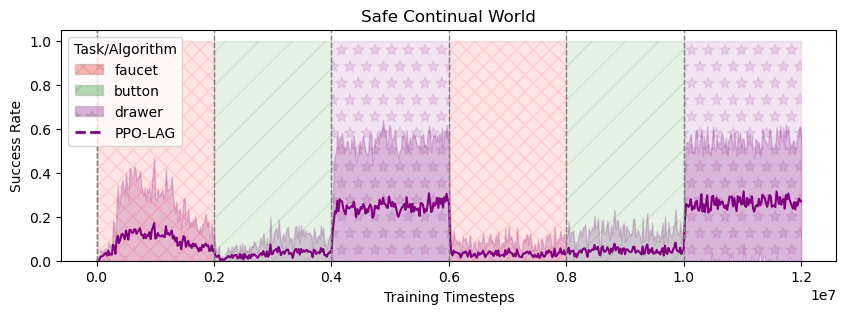

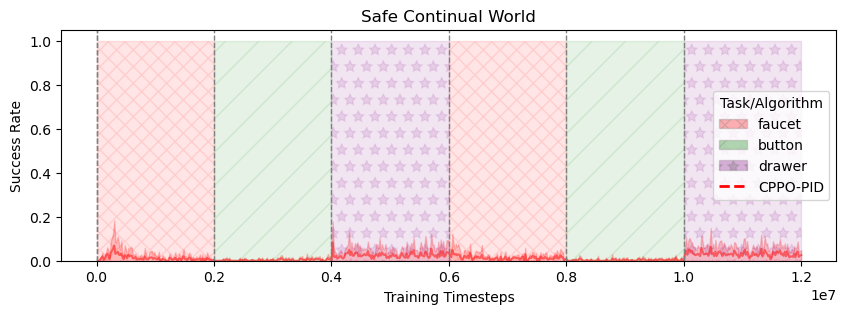

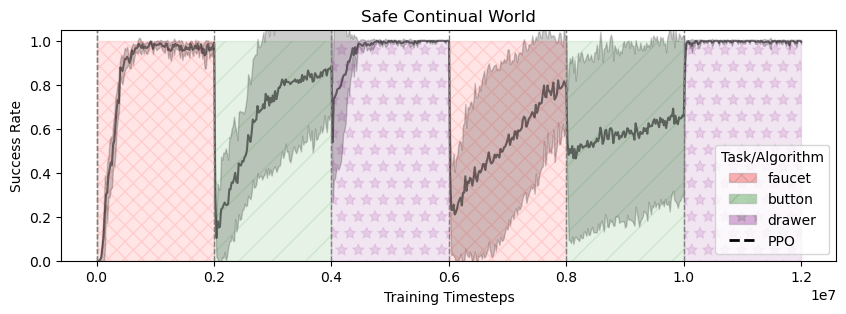

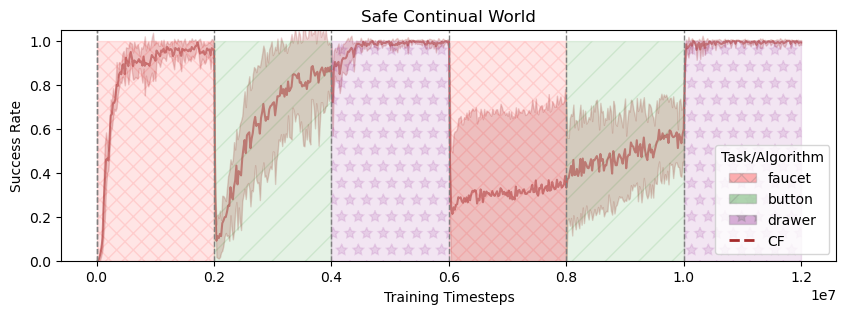

In [20]:
algorithms = ['PPO+EWC', 'CPO', 'Safe EWC', 'PPO-Lag', 'CPPO-PID', 'PPO', 'CF']
for algorithm in algorithms:
    plot_rewards([algorithm], 1.05, True, f'{algorithm}_cw_success')

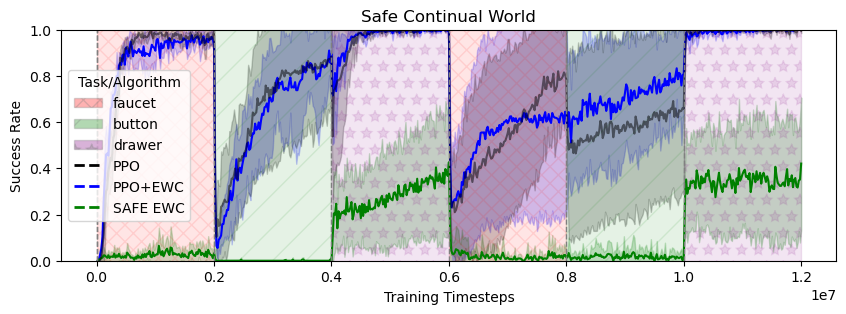

In [21]:
plot_rewards(['PPO', 'PPO+EWC', 'Safe EWC'], 1, False, f'PPO')

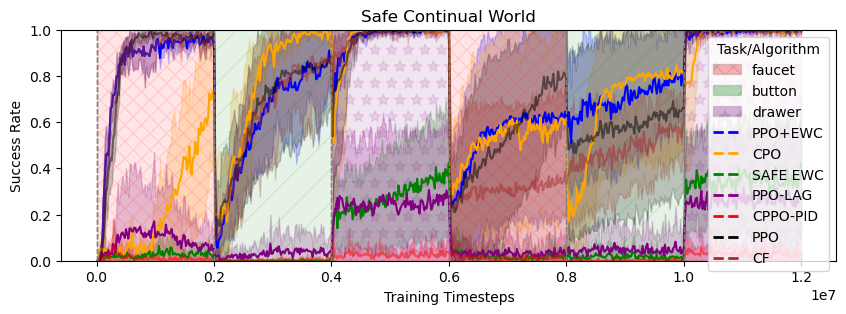

In [22]:
plot_rewards(algorithms, 1, True, f'all_cw_success')

In [45]:
def plot_costs(algorithms, ymax=None, save=False, name=None, xrange=None, bigger=False):
    # fig, ax = plt.subplots(figsize=(10,2)) 
    # plt.figure()
    # plt.figure(figsize=(3,3))

    if bigger:
        fig, ax = plt.subplots(figsize=(10,3))
    else:
        fig, ax = plt.subplots(figsize=(10,1))

    TASK_CYCLE =  ['faucet', 'button', 'drawer', 
                     'faucet', 'button', 'drawer']
    algorithm_colors={'PPO+EWC': 'blue', 
                    'CPO': 'purple',
                    'Safe EWC': 'green',
                    'PPO-Lag': 'orange',
                    'CPPO-PID': 'red',
                    'PPO': 'black',
                    'Exp. Replay': 'brown',
                    'CF': 'brown'}
    cycle_colors = {
        'faucet': 'red',
        'button': 'green',
        'drawer': 'purple'
    }

    cycle_hatches = {
        'faucet': 'xx',
        'button': '/',
        'drawer': '*'
    }

    if 'PPO+EWC' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], cw_ewc_mean_costs, label='PPO+EWC', color='blue')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_ewc_mean_costs - cw_ewc_std_costs,
            cw_ewc_mean_costs + cw_ewc_std_costs,
            color='blue', alpha=0.2
        )

    if 'CPO' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], cw_cpo_mean_costs, label='CPO', color='purple')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_cpo_mean_costs - cw_cpo_std_costs,
            cw_cpo_mean_costs + cw_cpo_std_costs,
            color='purple', alpha=0.2
        )

    if 'Safe EWC' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], safe_ewc_mean_costs, label='Safe EWC', color='green')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            safe_ewc_mean_costs - safe_ewc_std_costs,
            safe_ewc_mean_costs + safe_ewc_std_costs,
            color='green', alpha=0.2
        )

    if 'PPO-Lag' in algorithms:
        plt.plot(cw_ppolag_0['Train/TotalSteps'], cw_ppolag_mean_costs, label='PPO-Lag', color='orange')
        plt.fill_between(
            cw_ppolag_0['Train/TotalSteps'],
            cw_ppolag_mean_costs - cw_ppolag_std_costs,
            cw_ppolag_mean_costs + cw_ppolag_std_costs,
            color='orange', alpha=0.2
        )

    if 'CPPO-PID' in algorithms:
        plt.plot(cw_cppo_pid_0['Train/TotalSteps'], cw_cppo_pid_mean_costs, label='CPPO-PID', color='red', alpha=0.5)
        plt.fill_between(
            cw_cppo_pid_0['Train/TotalSteps'],
            cw_cppo_pid_mean_costs - cw_cppo_pid_std_costs,
            cw_cppo_pid_mean_costs + cw_cppo_pid_std_costs,
            color='red', alpha=0.2
        )

    if 'PPO' in algorithms:
        plt.plot(cw_ppo_0['Train/TotalSteps'], cw_ppo_mean_costs, label='PPO', color='black', alpha=0.5)
        plt.fill_between(
            cw_ppo_0['Train/TotalSteps'],
            cw_ppo_mean_costs - cw_ppo_std_costs,
            cw_ppo_mean_costs + cw_ppo_std_costs,
            color='black', alpha=0.2
        )

    if 'Exp. Replay' in algorithms:
        plt.plot(cw_clear_0['Train/TotalSteps'], cw_clear_mean_costs, label='Exp. Replay', color='brown', alpha=0.5)
        plt.fill_between(
            cw_clear_0['Train/TotalSteps'],
            cw_clear_mean_costs - cw_clear_std_costs,
            cw_clear_mean_costs + cw_clear_std_costs,
            color='brown', alpha=0.2
        )

    if 'CF' in algorithms:
        plt.plot(cw_ppo_0['Train/TotalSteps'], cw_cf_mean_costs, label='CF-EWC', color='brown', alpha=0.5)
        plt.fill_between(
            cw_ppo_0['Train/TotalSteps'],
            cw_cf_mean_costs - cw_cf_std_costs,
            cw_cf_mean_costs + cw_cf_std_costs,
            color='brown', alpha=0.2
        )

    x_vals = range(0, max(cw_cpo_0['Train/TotalSteps']) + 1, 2000000)
    for i, x in enumerate(x_vals[:-1]):  # Exclude the last x-value as it doesn't define a region
        # Get the current task from the cycle
        task = TASK_CYCLE[i % len(TASK_CYCLE)]
        
        # Shade the region between the current and next x value
        plt.axvline(x=x, color='gray', linestyle='--', linewidth=1)
        plt.fill_between([x, x_vals[i + 1]], cw_ppo_0['Metrics/EpCost'].min(), cw_ppo_0['Metrics/EpCost'].max(), color=cycle_colors[task],  hatch=cycle_hatches[task], alpha=0.1)

    plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='Task Change')

    legend_patches = []
    for task in cycle_colors:
        patch = mpatches.Patch(
            facecolor=cycle_colors[task], 
            hatch=cycle_hatches[task], 
            label=task,
            edgecolor='gray',  # Optional: add edgecolor to improve visibility in legend,
            alpha=0.3
        )
        legend_patches.append(patch)

    for algorithm in algorithms:
        custom_line = Line2D([0], [0], color=algorithm_colors[algorithm], lw=2, linestyle='-', label=algorithm.upper())
        legend_patches.append(custom_line)
    # Add legend to the plot
    # plt.legend(handles=legend_patches, title='Task/Algorithm', loc='lower center', bbox_to_anchor=(0.5, -1.6), ncol=7, shadow=True, columnspacing=0.6)
    if bigger:
        plt.legend(handles=legend_patches, title='Task/Algorithm', loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=5, shadow=True, columnspacing=0.6)
    else:
        plt.legend(handles=legend_patches, title='Task/Algorithm', loc='lower center', bbox_to_anchor=(0.5, -1.3), ncol=6, shadow=True, columnspacing=0.6)

    plt.xlabel("Training Timesteps")
    plt.ylabel("Cost")
    plt.title("Safe Continual World")
    if ymax is not None:
        plt.ylim(0, ymax)
    # plt.yscale('log')

    # from matplotlib.ticker import ScalarFormatter

    # ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    # ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  # Apply scientific notation to y-axis
    if xrange is not None:
        plt.xlim(xrange[0], xrange[1])

    if save:
        plt.savefig(f'./results/plots/{name}.png', bbox_inches='tight')

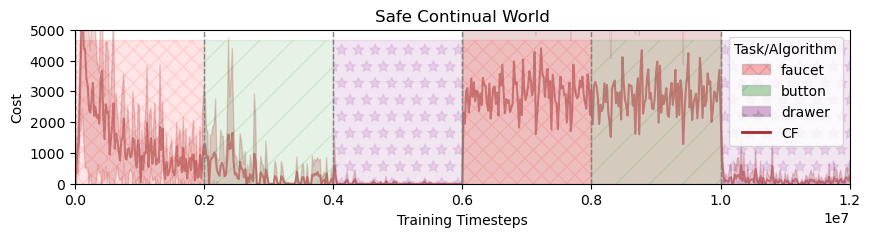

In [24]:
plot_costs(['CF'], 5000, True, 'cw_cost', (0, 12_000_000))

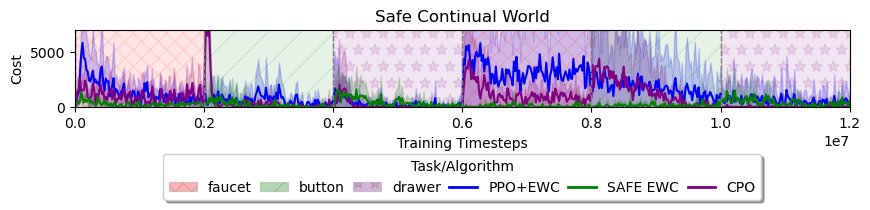

In [46]:
plot_costs(['PPO+EWC', 'Safe EWC', 'CPO'], 7000, False, 'cw_cost', (0, 12_000_000))

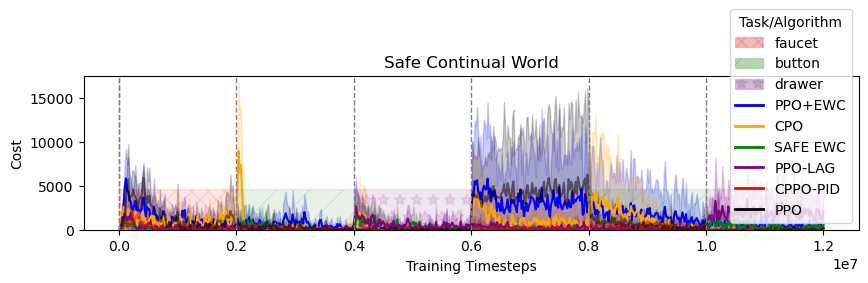

In [26]:
algorithms = ['PPO+EWC', 'CPO', 'Safe EWC', 'PPO-Lag', 'CPPO-PID', 'PPO']
plot_costs(algorithms, 17500, True, 'all_cw_cost')

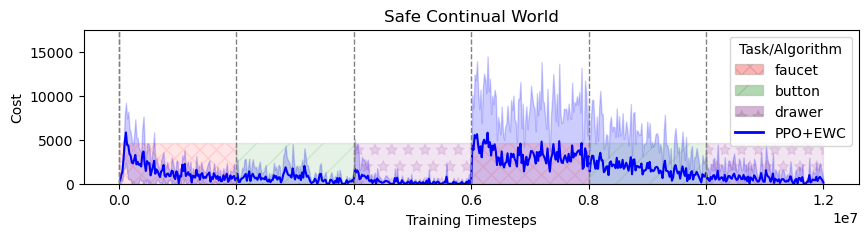

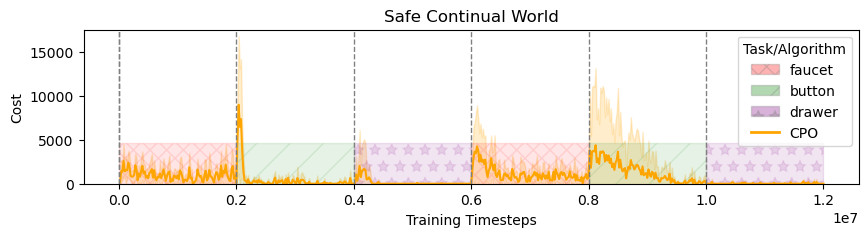

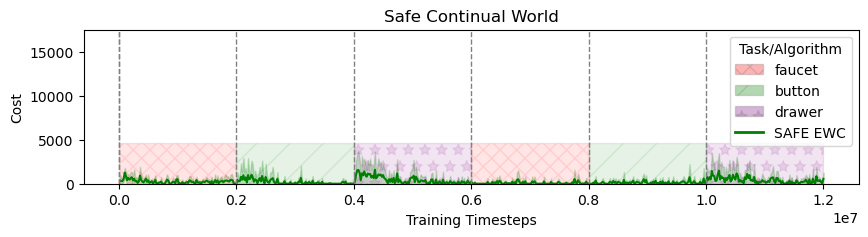

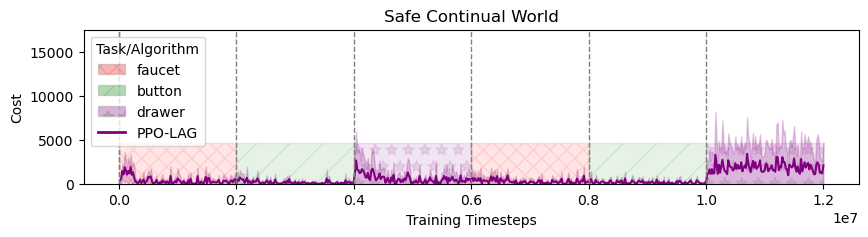

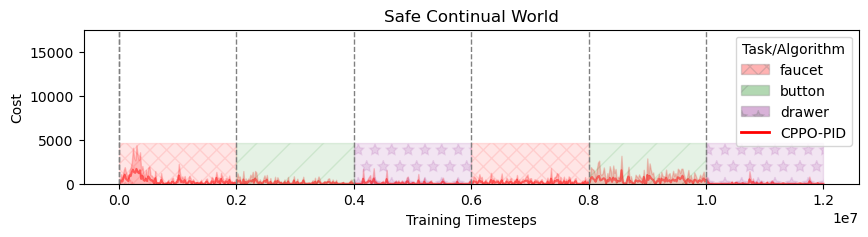

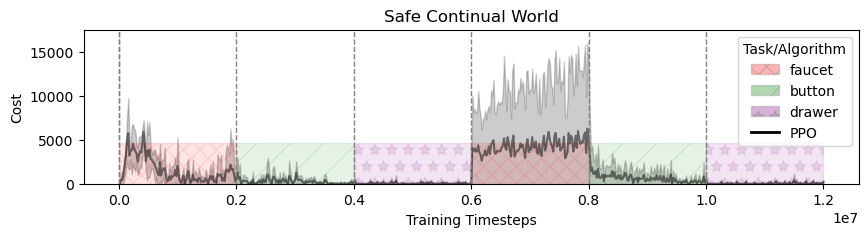

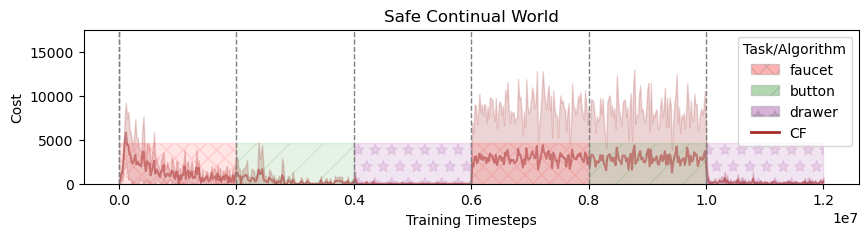

In [27]:
algorithms = ['PPO+EWC', 'CPO', 'Safe EWC', 'PPO-Lag', 'CPPO-PID', 'PPO', 'CF']
for algorithm in algorithms:
    plot_costs([algorithm], 17500, True, f'{algorithm}_cw_cost')

In [104]:
def plot_costs_task_change(
    algorithms,
    ymax=None,
    save=False,
    name=None,
    xrange=None,
    ax=None,
    show_legend=True
):
    # Create axis only if one is not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    else:
        fig = ax.figure

    TASK_CYCLE = ['faucet', 'button', 'drawer',
                  'faucet', 'button', 'drawer']

    algorithm_colors = {
        'PPO+EWC': 'blue',
        'CPO': 'orange',
        'Safe EWC': 'green',
        'PPO-Lag': 'purple',
        'CPPO-PID': 'red',
        'PPO': 'black',
        'Exp. Replay': 'brown'
    }

    cycle_colors = {
        'faucet': 'red',
        'button': 'green',
        'drawer': 'purple'
    }

    cycle_hatches = {
        'faucet': 'xx',
        'button': '/',
        'drawer': '*'
    }

    # --------------------
    # Algorithm plots
    # --------------------
    if 'PPO+EWC' in algorithms:
        ax.plot(cw_cpo_0['Train/TotalSteps'], cw_ewc_mean_costs,
                label='PPO+EWC', color='blue')
        ax.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_ewc_mean_costs - cw_ewc_std_costs,
            cw_ewc_mean_costs + cw_ewc_std_costs,
            color='blue', alpha=0.2
        )

    if 'CPO' in algorithms:
        ax.plot(cw_cpo_0['Train/TotalSteps'], cw_cpo_mean_costs,
                label='CPO', color='orange')
        ax.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_cpo_mean_costs - cw_cpo_std_costs,
            cw_cpo_mean_costs + cw_cpo_std_costs,
            color='orange', alpha=0.2
        )

    if 'Safe EWC' in algorithms:
        ax.plot(cw_cpo_0['Train/TotalSteps'], safe_ewc_mean_costs,
                label='Safe EWC', color='green')
        ax.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            safe_ewc_mean_costs - safe_ewc_std_costs,
            safe_ewc_mean_costs + safe_ewc_std_costs,
            color='green', alpha=0.2
        )

    if 'PPO-Lag' in algorithms:
        ax.plot(cw_ppolag_0['Train/TotalSteps'], cw_ppolag_mean_costs,
                label='PPO-Lag', color='purple')
        ax.fill_between(
            cw_ppolag_0['Train/TotalSteps'],
            cw_ppolag_mean_costs - cw_ppolag_std_costs,
            cw_ppolag_mean_costs + cw_ppolag_std_costs,
            color='purple', alpha=0.2
        )

    if 'CPPO-PID' in algorithms:
        ax.plot(cw_cppo_pid_0['Train/TotalSteps'], cw_cppo_pid_mean_costs,
                label='CPPO-PID', color='red', alpha=0.5)
        ax.fill_between(
            cw_cppo_pid_0['Train/TotalSteps'],
            cw_cppo_pid_mean_costs - cw_cppo_pid_std_costs,
            cw_cppo_pid_mean_costs + cw_cppo_pid_std_costs,
            color='red', alpha=0.2
        )

    if 'PPO' in algorithms:
        ax.plot(cw_ppo_0['Train/TotalSteps'], cw_ppo_mean_costs,
                label='PPO', color='black', alpha=0.5)
        ax.fill_between(
            cw_ppo_0['Train/TotalSteps'],
            cw_ppo_mean_costs - cw_ppo_std_costs,
            cw_ppo_mean_costs + cw_ppo_std_costs,
            color='black', alpha=0.2
        )

    if 'Exp. Replay' in algorithms:
        ax.plot(cw_clear_0['Train/TotalSteps'], cw_clear_mean_costs,
                label='Exp. Replay', color='brown', alpha=0.5)
        ax.fill_between(
            cw_clear_0['Train/TotalSteps'],
            cw_clear_mean_costs - cw_clear_std_costs,
            cw_clear_mean_costs + cw_clear_std_costs,
            color='brown', alpha=0.2
        )

    # --------------------
    # Task change shading
    # --------------------
    x_vals = range(0, max(cw_cpo_0['Train/TotalSteps']) + 1, 2_000_000)

    ymin = min(cw_ppo_0['Metrics/EpCost'])
    ymax_fill = max(cw_ppo_0['Metrics/EpCost'])

    for i, x in enumerate(x_vals[:-1]):
        task = TASK_CYCLE[i % len(TASK_CYCLE)]

        ax.axvline(x=x, color='gray', linestyle='--', linewidth=2)
        ax.fill_between(
            [x, x_vals[i + 1]],
            ymin, ymax_fill,
            color=cycle_colors[task],
            hatch=cycle_hatches[task],
            alpha=0.1
        )

    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)

    # --------------------
    # Legend
    # --------------------
    legend_handles = []
    for algorithm in algorithms:
        legend_handles.append(
            Line2D(
                [0], [0],
                color=algorithm_colors[algorithm],
                lw=2,
                linestyle='--',
                label=algorithm.upper()
            )
        )

    if show_legend:
        ax.legend(handles=legend_handles, title='Algorithm', loc='upper left')

    # --------------------
    # Labels & limits
    # --------------------
    ax.set_xlabel("Training Timesteps")
    ax.set_ylabel("Cost")
    ax.set_title("Cost at Task Change")

    if ymax is not None:
        ax.set_ylim(0, ymax)

    if xrange is not None:
        ax.set_xlim(xrange)

    # --------------------
    # Save if requested
    # --------------------
    if save:
        fig.savefig(f'./results/plots/{name}.png', bbox_inches='tight')

    return ax


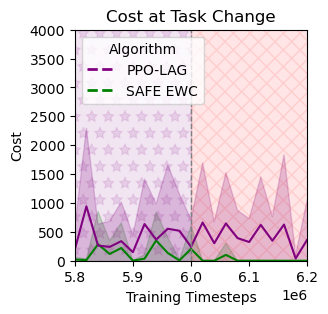

In [51]:
plot_costs_task_change(['PPO-Lag', 'Safe EWC'], 4000, True, 'cost_task_change', (5_800_000, 6_200_000))

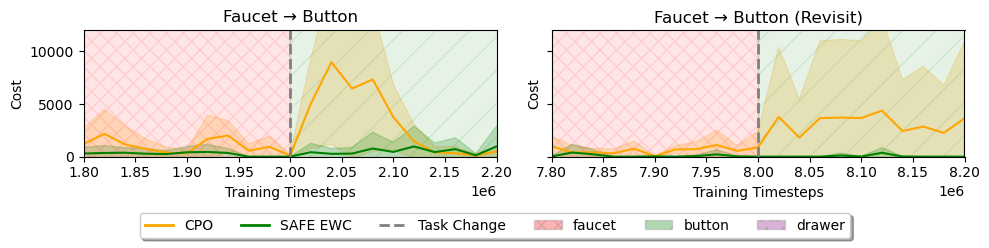

In [112]:
# --------------------
# Configuration
# --------------------
methods = ['CPO', 'Safe EWC']
window_half_width = 200_000

marks = [2_000_000, 4_000_000, 6_000_000, 8_000_000, 10_000_000]
task_order = [
    'Faucet → Button',
    'Button → Drawer',
    'Drawer → Faucet (Revisit)',
    'Faucet → Button (Revisit)',
    'Button → Drawer (Revisit)'
]

include_idx = [0, 3]   # <--- SELECT SUBFIGURES HERE

# --------------------
# Select only desired panels
# --------------------
selected_marks = [marks[i] for i in include_idx]
selected_tasks = [task_order[i] for i in include_idx]

# --------------------
# Figure + axes (one row)
# --------------------
fig, axes = plt.subplots(
    1,
    len(selected_marks),
    figsize=(5 * len(selected_marks), 2.5),
    sharey=True
)

if len(selected_marks) == 1:
    axes = [axes]

# --------------------
# Plot panels
# --------------------
for ax, mark, task in zip(axes, selected_marks, selected_tasks):
    plot_costs_task_change(
        methods,
        ymax=12000,
        save=False,
        xrange=(mark - window_half_width, mark + window_half_width),
        ax=ax,
        show_legend=False
    )
    ax.set_title(task)

# --------------------
# Shared legend
# --------------------
algorithm_colors = {
    'PPO+EWC': 'blue',
    'CPO': 'orange',
    'Safe EWC': 'green',
    'PPO-Lag': 'purple',
    'CPPO-PID': 'red',
    'PPO': 'black',
    'Exp. Replay': 'brown',
    'CF': 'brown'
}

cycle_colors = {
    'faucet': 'red',
    'button': 'green',
    'drawer': 'purple'
}

cycle_hatches = {
    'faucet': 'xx',
    'button': '/',
    'drawer': '*'
}

legend_handles = []

# Algorithm lines
for algorithm in methods:
    legend_handles.append(
        Line2D(
            [0], [0],
            color=algorithm_colors[algorithm],
            lw=2,
            linestyle='-',
            label=algorithm.upper()
        )
    )

# Task-change line
legend_handles.append(
    Line2D(
        [0], [0],
        color='gray',
        lw=2,
        linestyle='--',
        label='Task Change'
    )
)

# Task shading
for task in cycle_colors:
    legend_handles.append(
        mpatches.Patch(
            facecolor=cycle_colors[task],
            hatch=cycle_hatches[task],
            label=task,
            edgecolor='gray',
            alpha=0.3
        )
    )

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles),
    frameon=True,
    shadow=True,
    bbox_to_anchor=(0.5, -0)
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()